# MOTOR 1: OTIMIZADOR DE TRAÇADO E GRAFOS VIÁRIOS (VLT)
# Objetivo: Calcular matematicamente a rota de menor custo e impacto pela malha real da cidade

In [128]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import networkx as nx
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import folium
import numpy as np

print("Ambiente Global configurado com sucesso!")

Ambiente Global configurado com sucesso!


Baixando malha viária de João Pessoa, Paraíba, Brazil... (Isso pode levar alguns segundos)


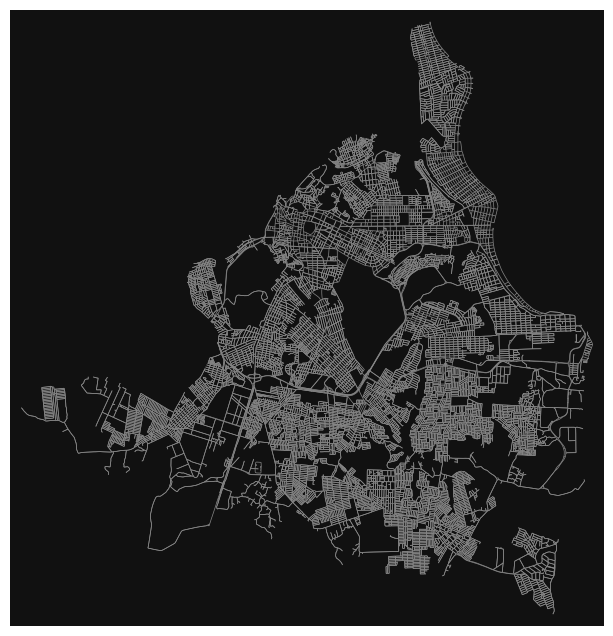

In [129]:
# Baixando ruas de qualquer lugar do mundo
cidade = "João Pessoa, Paraíba, Brazil"
print(f"Baixando malha viária de {cidade}... (Isso pode levar alguns segundos)")

# Baixa a rede de ruas para dirigir/VLT (drive)
grafo_ruas = ox.graph_from_place(cidade, network_type='drive')

nos, arestas = ox.graph_to_gdfs(grafo_ruas)

# Plota o mapa de ruas na tela para visualizarmos
fig, ax = ox.plot_graph(grafo_ruas, node_size=0, edge_color="#888888", edge_linewidth=0.5)

In [130]:
# Lendo os dados

arq_relevo = rasterio.open('dados/relevo_jp.tif')

tags_ambientais = {
    'leisure': 'nature_reserve',
    'boundary': 'protected_area',
    'landuse': 'forest'
}
reservas = ox.features_from_place(cidade, tags=tags_ambientais)

# Ordena a tabela alfabeticamente pelo nome, jogando os NaN (vazios) para o final
reservas_organizadas = reservas.sort_values(by='name', na_position='last')

print("Largura em pixels:", arq_relevo.width)
print("Altura em pixels:", arq_relevo.height)
print("Sucesso! O Python leu o arquivo de relevo.")
# Mostra apenas as colunas de nome e geometria para conferir
reservas_organizadas[['name']].head(6)

Largura em pixels: 5400
Altura em pixels: 3600
Sucesso! O Python leu o arquivo de relevo.


name
element  id                                                       
way      255739402       Floresta Nacional da Restinga de Cabedelo
         79127143                                Mata Externa UFPB
         1462395915   Refúgio de Vida Silvestre Mata do Buraquinho
         1462397439  Área de Proteção Ambiental Naufrágio Queimado
relation 5371614                                               NaN
         12847166                                              NaN

In [131]:
# Plotando mapa de preservação
mapa_reservas = folium.Map(location=[-7.1150, -34.8906], zoom_start=12)

folium.GeoJson(
    reservas,
    name='Áreas Verdes e Reservas',
    style_function=lambda x: {
        'fillColor': 'green',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.6
    },
    tooltip=folium.GeoJsonTooltip(fields=['name'], aliases=['Nome:'])
).add_to(mapa_reservas)

folium.LayerControl().add_to(mapa_reservas)
mapa_reservas


In [132]:
crs_arestas_origin = arestas.crs

arestas = arestas.to_crs(epsg=31985)
arestas['ponto_inicio'] = arestas.geometry.interpolate(0.0, normalized=True)
arestas['ponto_meio'] = arestas.geometry.interpolate(0.5, normalized=True)
arestas['ponto_fim'] = arestas.geometry.interpolate(1.0, normalized=True)

arestas.head()

osmid  \
u         v          key                                                      
324817308 7187131525 0                                            246441628   
          3552601996 0                                            356319614   
324817350 2052120227 0                                            194708197   
          1869474390 0    [1304634159, 300146671, 1418708243, 1418708244...   
337591192 818939265  0                                             46916402   

                              highway lanes  maxspeed  \
u         v          key                                
324817308 7187131525 0          trunk     2        80   
          3552601996 0    residential   NaN       NaN   
324817350 2052120227 0     trunk_link   NaN       NaN   
          1869474390 0          trunk     2  [80, 60]   
337591192 818939265  0    residential   NaN       NaN   

                                                        name  oneway  \
u         v          key                                               
324817308 7187131525 0        Rodovia Governador Mário Covas    True   
          3552601996 0                        Rua Domésticas   False   
324817350 2052120227 0                                   NaN    True   
          1869474390 0      Rodovia Governador Antônio Mariz    True   
337591192 818939265  0    Rua Lionildo Francisco de Oliveira   False   

                                    ref reversed      length  \
u         v          key                                       
324817308 7187131525 0    BR-101;BR-230    False  345.413469   
          3552601996 0              NaN     True  286.706860   
324817350 2052120227 0              NaN    False  234.041369   
          1869474390 0    BR-230;PB-008    False  947.842713   
337591192 818939265  0              NaN     True   67.417563   

                                                                   geometry  \
u         v          key                                                      
324817308 7187131525 0    LINESTRING (289608.049 9208059.536, 289623.877...   
          3552601996 0    LINESTRING (289608.049 9208059.536, 289611.773...   
324817350 2052120227 0    LINESTRING (296198.134 9211889.363, 296204.412...   
          1869474390 0    LINESTRING (296198.134 9211889.363, 296205.615...   
337591192 818939265  0    LINESTRING (295279.357 9213627.705, 295265.085...   

                         bridge junction access tunnel  \
u         v          key                                 
324817308 7187131525 0      NaN      NaN    NaN    NaN   
          3552601996 0      NaN      NaN    NaN    NaN   
324817350 2052120227 0      NaN      NaN    NaN    NaN   
          1869474390 0      NaN      NaN    NaN    NaN   
337591192 818939265  0      NaN      NaN    NaN    NaN   

                                            ponto_inicio  \
u         v          key                                   
324817308 7187131525 0    POINT (289608.049 9208059.536)   
          3552601996 0    POINT (289608.049 9208059.536)   
324817350 2052120227 0    POINT (296198.134 9211889.363)   
          1869474390 0    POINT (296198.134 9211889.363)   
337591192 818939265  0    POINT (295279.357 9213627.705)   

                                              ponto_meio  \
u         v          key                                   
324817308 7187131525 0    POINT (289742.344 9207951.476)   
          3552601996 0    POINT (289705.349 9207956.188)   
324817350 2052120227 0    POINT (296260.064 9211985.584)   
          1869474390 0     POINT (296224.37 9212358.965)   
337591192 818939265  0    POINT (295272.221 9213660.477)   

                                               ponto_fim  
u         v          key                                  
324817308 7187131525 0     POINT (289878.58 9207845.689)  
          3552601996 0    POINT (289816.907 9207868.639)  
324817350 2052120227 0    POINT (296374.113 9212000.626)  
          1869474390 0    POINT (296362.321 9212765.599)  
33759

In [133]:
# adicionando os pesos nas ruas 
arestas['edge_weight'] = arestas['length']

arestas['edge_weight'] = np.where(
    arestas['highway'] == 'residential', #condição
    arestas['edge_weight'] * 5, #true (x5)
    arestas['edge_weight'] #false (mantem)
)

all_reservas = reservas.geometry.union_all()

arestas['edge_weight'] = np.where(
    arestas.geometry.intersects(all_reservas),
    float('inf'),
    arestas['edge_weight']
)

arestas.head()

osmid  \
u         v          key                                                      
324817308 7187131525 0                                            246441628   
          3552601996 0                                            356319614   
324817350 2052120227 0                                            194708197   
          1869474390 0    [1304634159, 300146671, 1418708243, 1418708244...   
337591192 818939265  0                                             46916402   

                              highway lanes  maxspeed  \
u         v          key                                
324817308 7187131525 0          trunk     2        80   
          3552601996 0    residential   NaN       NaN   
324817350 2052120227 0     trunk_link   NaN       NaN   
          1869474390 0          trunk     2  [80, 60]   
337591192 818939265  0    residential   NaN       NaN   

                                                        name  oneway  \
u         v          key                                               
324817308 7187131525 0        Rodovia Governador Mário Covas    True   
          3552601996 0                        Rua Domésticas   False   
324817350 2052120227 0                                   NaN    True   
          1869474390 0      Rodovia Governador Antônio Mariz    True   
337591192 818939265  0    Rua Lionildo Francisco de Oliveira   False   

                                    ref reversed      length  \
u         v          key                                       
324817308 7187131525 0    BR-101;BR-230    False  345.413469   
          3552601996 0              NaN     True  286.706860   
324817350 2052120227 0              NaN    False  234.041369   
          1869474390 0    BR-230;PB-008    False  947.842713   
337591192 818939265  0              NaN     True   67.417563   

                                                                   geometry  \
u         v          key                                                      
324817308 7187131525 0    LINESTRING (289608.049 9208059.536, 289623.877...   
          3552601996 0    LINESTRING (289608.049 9208059.536, 289611.773...   
324817350 2052120227 0    LINESTRING (296198.134 9211889.363, 296204.412...   
          1869474390 0    LINESTRING (296198.134 9211889.363, 296205.615...   
337591192 818939265  0    LINESTRING (295279.357 9213627.705, 295265.085...   

                         bridge junction access tunnel  \
u         v          key                                 
324817308 7187131525 0      NaN      NaN    NaN    NaN   
          3552601996 0      NaN      NaN    NaN    NaN   
324817350 2052120227 0      NaN      NaN    NaN    NaN   
          1869474390 0      NaN      NaN    NaN    NaN   
337591192 818939265  0      NaN      NaN    NaN    NaN   

                                            ponto_inicio  \
u         v          key                                   
324817308 7187131525 0    POINT (289608.049 9208059.536)   
          3552601996 0    POINT (289608.049 9208059.536)   
324817350 2052120227 0    POINT (296198.134 9211889.363)   
          1869474390 0    POINT (296198.134 9211889.363)   
337591192 818939265  0    POINT (295279.357 9213627.705)   

                                              ponto_meio  \
u         v          key                                   
324817308 7187131525 0    POINT (289742.344 9207951.476)   
          3552601996 0    POINT (289705.349 9207956.188)   
324817350 2052120227 0    POINT (296260.064 9211985.584)   
          1869474390 0     POINT (296224.37 9212358.965)   
337591192 818939265  0    POINT (295272.221 9213660.477)   

                                               ponto_fim  edge_weight  
u         v          key                                               
324817308 7187131525 0     POINT (289878.58 9207845.689)   345.413469  
          3552601996 0    POINT (289816.907 9207868.639)  1433.534298  
324817350 2052120227 0    POINT (296374.113 9212000.626)   234.041369  

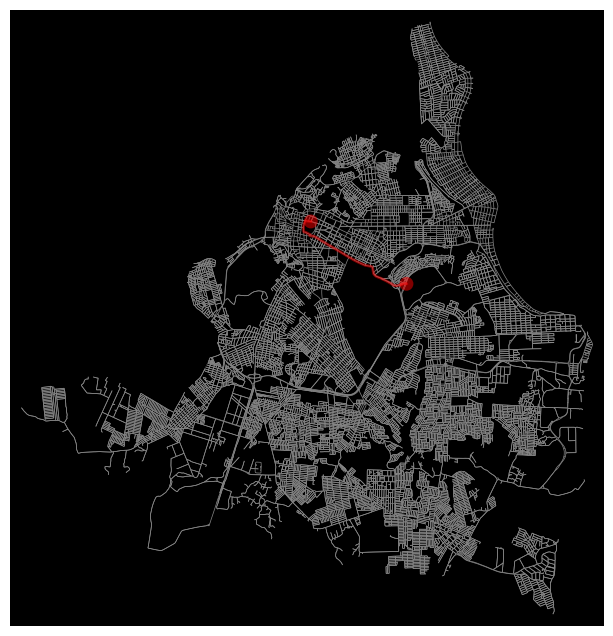

In [134]:
# Dados da origem e destino
origin_lat = -7.118200
origin_lon = -34.87949

destination_lat = -7.13746
destination_lon = -34.85040

origin_node = ox.distance.nearest_nodes(grafo_ruas, origin_lon, origin_lat)
destination_node = ox.distance.nearest_nodes(grafo_ruas, destination_lon, destination_lat)

route = nx.shortest_path(grafo_ruas, origin_node, destination_node, weight='length')

fig, ax = ox.plot_graph_route(
    grafo_ruas, route, 
    route_color='red', 
    route_linewidth=2,        # Afina a linha do VLT
    node_size=0,              # Esconde as bolinhas dos cruzamentos
    bgcolor='black',          # Fundo branco
    edge_color="#888888",     # Ruas de fundo bem clarinhas
    edge_linewidth=0.5        # Ruas de fundo bem finas
)

In [135]:
import folium

# 1. Extrai as coordenadas (Lat, Lng) de cada esquina que o algoritmo escolheu
coordenadas_rota = [(grafo_ruas.nodes[no]['y'], grafo_ruas.nodes[no]['x']) for no in route]

# 2. Criamos o mapa interativo do Folium (igual ao seu projeto antigo)
mapa_vlt = folium.Map(location=[origin_lat, origin_lon], zoom_start=13)

# 3. Desenha a linha do VLT acompanhando perfeitamente as ruas
folium.PolyLine(
    locations=coordenadas_rota, 
    color='red', 
    weight=5, 
    tooltip='Rota Otimizada do VLT'
).add_to(mapa_vlt)

# 4. Adiciona os marcadores de Origem e Destino
folium.Marker([origin_lat, origin_lon], popup='Centro (Lagoa)', icon=folium.Icon(color='green', icon='train', prefix='fa')).add_to(mapa_vlt)
folium.Marker([destination_lat, destination_lon], popup='Bancários/UFPB', icon=folium.Icon(color='blue', icon='train', prefix='fa')).add_to(mapa_vlt)

mapa_vlt